# initial imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os

In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [4]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# get data

In [8]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)

SearchResult containing 28 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 18 TESS Sector 73 2023   SPOC     120   269701147      0.0
 19 TESS Sector 75 2024   SPOC     120   269701147      0.0
 20 TESS Sector 76 2024   SPOC     120   269701147      0

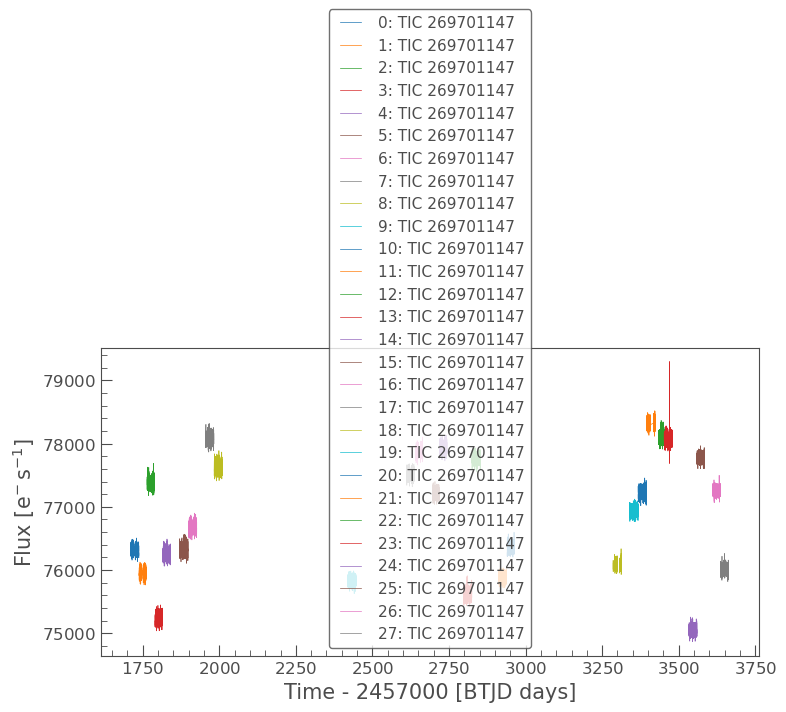

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [10]:
lc_collection = search_result.download_all()
lc_collection.plot()
plt.show()
print(lc_collection)

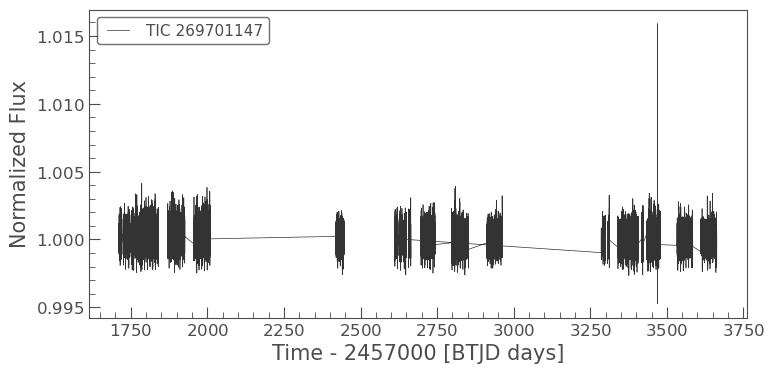

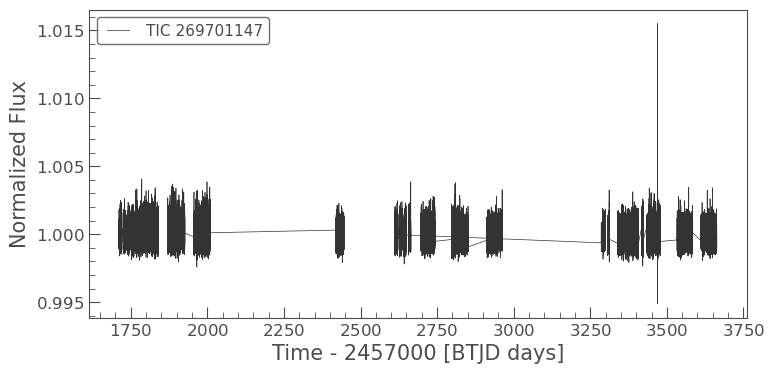

In [20]:
# Stitch all the light curves together into a single LightCurve object
lc = lc_collection.stitch()

# Plot the raw light curve
lc.plot(title="Raw Light Curve")
plt.show()

# Detrend (flatten) the light curve
lc_flat = lc.flatten(window_length=401)  # Adjust window_length if needed

# Plot the detrended light curve
lc_flat.plot(title="Detrended Light Curve")
plt.show()


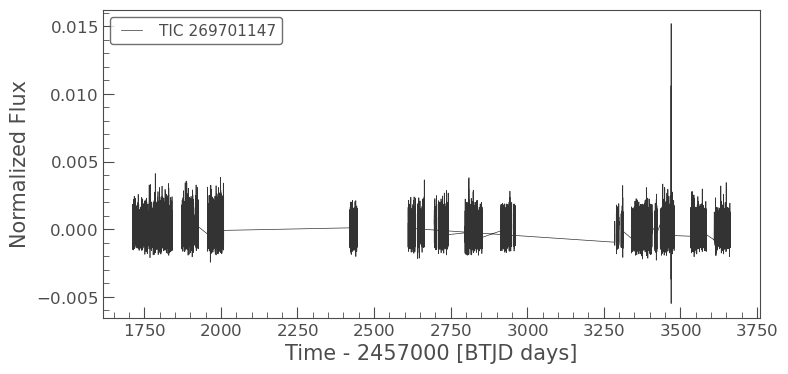

In [21]:
from scipy.signal import savgol_filter

# Apply Savitzky-Golay filter to model the variability
trend = savgol_filter(lc.flux, window_length=401, polyorder=2)

# Subtract trend to get detrended flux
flux_detrended = lc.flux - trend

# Create a new LightCurve object with detrended flux
lc_detrended = lc.copy()
lc_detrended.flux = flux_detrended

# Plot
lc_detrended.plot(title="Custom Savitzky-Golay Detrending")
plt.show()


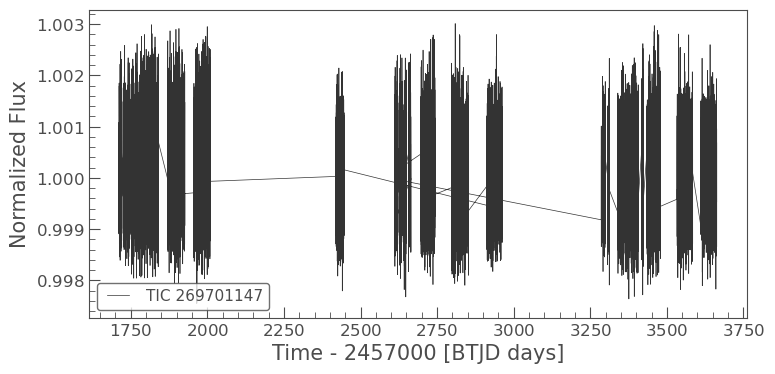

In [23]:
lc_clean = lc.remove_outliers(sigma=6)  # Clean before detrending
lc_flat = lc_clean.flatten(window_length=401, polyorder=2)
lc_flat.plot(title="Detrended Light Curve After Outlier Removal")
plt.show()